In [1]:
# ==============================
# Spark Session
# ==============================
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("US Accidents Viewer") \
    .getOrCreate()

# ==============================
# Path del tuo CSV
# ==============================
csv_path = "../us_accidents_cleaned(1_dp)/cleanedUS.csv"

# ==============================
# Carica CSV con Spark
# ==============================
df = spark.read.csv(
    csv_path,
    header=True,
    inferSchema=True
)

import pandas as pd
# ==============================
# Converti prime 5000 righe in Pandas
#     (se ne metti troppo poche la tabella è piccola,
#      5000 funziona benissimo per scorrere)
# ==============================
pdf = df.limit(5000).toPandas()

# ==============================
# Imposta Pandas per mostrare
#     TUTTE le colonne SENZA troncamento
# ==============================

pd.set_option('display.max_columns', None)     # mostra tutte le colonne
pd.set_option('display.max_colwidth', None)    # non tronca il contenuto
pd.set_option('display.width', None)           # evita di andare a capo

# ==============================
# Mostra tabella scorrevole
# ==============================
pdf

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/10 12:41:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/10 12:41:23 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/01/10 12:41:48 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,weather_grouped,State,Month,Humidity(%),Precipitation(in),ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Description,City,County,Timezone,Temperature(F),Visibility(mi),Wind_Direction,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Year,Day,Weekday,Hour,Wind_Speed(mph)
0,Fog/Haze,CO,4,4.0,0.0,A-4826631,Source1,2,2022-04-22 17:58:30,2022-04-22 18:11:30,40.362600,-103.421935,4.846,Stationary traffic on I-76 E from CR-Q/Exit 102 (I-76) to CO-63/Exit 115 (I-76) due to accident.,Akron,Washington,US/Mountain,85.0,0.75,S,False,False,False,False,False,False,False,False,False,False,False,False,False,0,2022,22,6,17,31.0
1,Fog/Haze,CO,4,36.0,0.0,A-3892673,Source1,2,2022-04-15 21:39:01,2022-04-15 22:55:53,39.784981,-105.048705,0.963,Incident on I-70 EB near LOWELL BLVD Road closed. Take alternate route.,Denver,Denver,US/Mountain,41.0,10.00,NE,False,False,False,False,False,False,False,False,False,False,False,False,False,1,2022,15,6,21,8.0
2,Fog/Haze,CO,4,36.0,0.0,A-4395954,Source1,2,2022-04-15 21:39:01,2022-04-15 22:55:53,39.784981,-105.048705,0.963,Incident on I-70 EB near LOWELL BLVD Road closed. Take alternate route.,Denver,Denver,US/Mountain,41.0,10.00,NE,False,False,False,False,False,False,False,False,False,False,False,False,False,1,2022,15,6,21,8.0
3,Fog/Haze,CO,4,36.0,0.0,A-4694963,Source1,2,2022-04-15 21:39:01,2022-04-16 00:01:01,39.783758,-105.034586,0.050,At Exit 271B: Lowell Boulevard (Denver) at Mile Point 271.5. Road closed expect delays due to a crash.,Denver,Denver,US/Mountain,41.0,10.00,NE,False,False,True,True,False,False,False,False,False,True,False,False,False,1,2022,15,6,21,8.0
4,Fog/Haze,CO,4,36.0,0.0,A-5200458,Source1,2,2022-04-15 21:39:01,2022-04-15 23:43:01,39.783758,-105.034586,0.050,At Exit 271B: Lowell Boulevard (Denver) at Mile Point 271.5. Road closed expect delays due to a crash.,Denver,Denver,US/Mountain,41.0,10.00,NE,False,False,True,True,False,False,False,False,False,True,False,False,False,1,2022,15,6,21,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Cloudy,UT,4,21.0,0.0,A-7712187,Source1,2,2019-04-20 12:37:00,2019-04-20 13:45:00,40.724280,-111.924490,0.042,At 9th/Exit 17 - Accident.,West Valley City,Salt Lake,US/Mountain,73.0,10.00,S,False,False,False,False,False,False,False,False,False,False,False,False,False,0,2019,20,7,12,16.0
4996,Cloudy,UT,4,21.0,0.0,A-7712188,Source1,2,2019-04-20 12:37:00,2019-04-20 13:45:00,40.724450,-111.923890,0.042,At UT-68/Redwood Road/Exit 16 - Accident.,West Valley City,Salt Lake,US/Mountain,73.0,10.00,S,False,False,False,False,False,False,False,False,False,False,False,False,False,0,2019,20,7,12,16.0
4997,Cloudy,UT,4,21.0,0.0,A-7712193,Source1,2,2019-04-20 13:13:00,2019-04-20 14:11:00,40.748950,-112.178840,0.696,At UT-202/Exit 104 - Accident.,Magna,Salt Lake,US/Mountain,73.0,10.00,S,False,False,False,False,False,False,False,False,False,False,False,False,False,0,2019,20,7,13,16.0
4998,Cloudy,UT,4,21.0,0.0,A-1555180,Source2,2,2020-04-14 13:09:04,2020-04-14 14:08:46,40.500427,-111.935524,0.000,Right hand shoulder blocked due to accident on UT-154 Bangerter Hwy Westbound at Exit 3 UT-68 Redwood Rd.,Riverton,Salt Lake,US/Mountain,47.0,10.00,N,False,False,False,False,False,False,False,False,False,False,False,False,False,0,2020,14,3,13,8.0


In [3]:
from pyspark.sql.functions import md5, concat_ws

# colonne da usare per il confronto (escludiamo ID)
cols_no_id = [c for c in df.columns if c != "ID"]

# creiamo hash di riga
df = (
    df
    .withColumn("row_hash", md5(concat_ws("||", *cols_no_id)))
    .dropDuplicates(["row_hash"])
    .drop("row_hash")
)

print("Numero righe dopo deduplicazione:", df.count())

Numero righe dopo deduplicazione: 7485236


In [5]:
#check di sicurezza 
from pyspark.sql import functions as F

dup_check = (
    df
    .groupBy(df.columns)
    .count()
    .filter(F.col("count") > 1)
)

print("Duplicati rimasti:", dup_check.count())

Duplicati rimasti: 0


In [6]:
df.coalesce(1) \
  .write \
  .mode("overwrite") \
  .option("header", True) \
  .csv("../us_accidents_cleaned2")


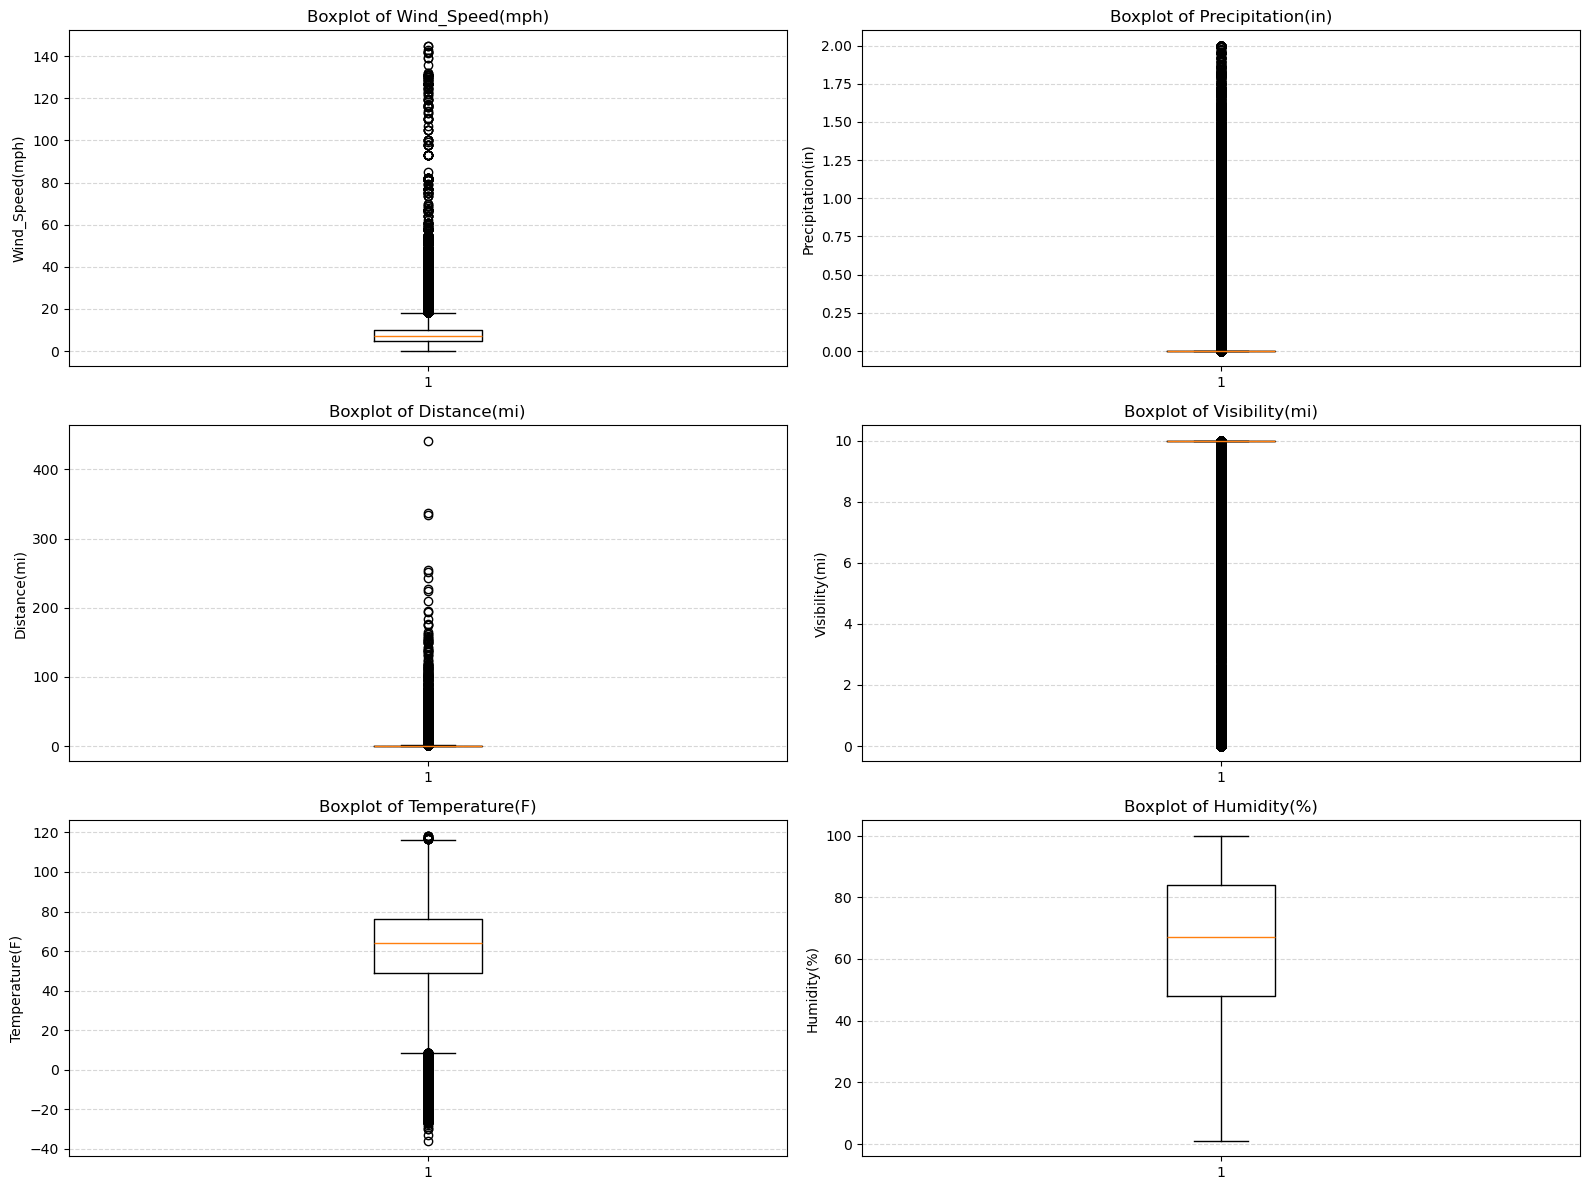

In [7]:
import matplotlib.pyplot as plt

cols = [
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Distance(mi)",
    "Visibility(mi)",
    "Temperature(F)",
    "Humidity(%)"
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(cols, 1):
    pdf_col = df.select(col).toPandas()
    
    plt.subplot(3, 2, i)
    plt.boxplot(pdf_col[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
